In [ ]:
!pip install -q transformers torch scikit-learn pandas matplotlib

import os
os.environ["WANDB_DISABLED"] = "true"


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI_vs_Human_Text_Dataset.csv")

print(df.shape)
df.head()


(10000, 3)


,id,text,label
0,6252,Climate change poses significant challenges to...,1
1,4684,There are alot of books available in market fo...,0
2,1731,The film starts with a man obsessed with compu...,0
3,4742,Please note that B12 isn't dangerous at all if...,0
4,4521,Your face breaks out like a 14 year old (teena...,0


In [ ]:
df = df.dropna(subset=["text", "label"])
df["label"] = df["label"].astype(int)

df["label"].value_counts()


,count
label,
1,5000
0,5000


In [ ]:
texts = df["text"].astype(str).tolist()
labels = df["label"].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


In [ ]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

train_enc = tokenizer(
    X_train,
    truncation=True,
    padding=True,
    max_length=256
)

val_enc = tokenizer(
    X_val,
    truncation=True,
    padding=True,
    max_length=256
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [ ]:
train_ds = TextDataset(train_enc, y_train)
val_ds   = TextDataset(val_enc, y_val)


In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    do_train=True,
    do_eval=True,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./bert_logs"
)


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss
500,0.016600
1000,0.000100
1500,0.000000


TrainOutput(global_step=1500, training_loss=0.005549559230605761, metrics={'train_runtime': 1050.1496, 'train_samples_per_second': 22.854, 'train_steps_per_second': 1.428, 'total_flos': 3157332664320000.0, 'train_loss': 0.005549559230605761, 'epoch': 3.0})

In [ ]:
trainer.evaluate()


In [ ]:
preds = trainer.predict(val_ds)

y_true = preds.label_ids
y_pred = preds.predictions.argmax(axis=1)
y_prob = torch.softmax(
    torch.tensor(preds.predictions), dim=1
).numpy()[:, 1]


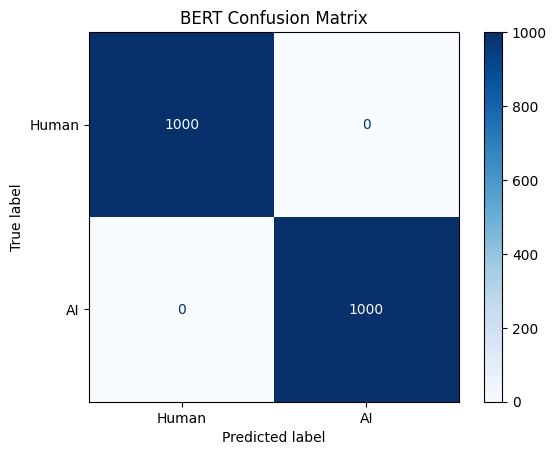

In [ ]:
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
).plot(cmap="Blues")

plt.title("BERT Confusion Matrix")
plt.show()


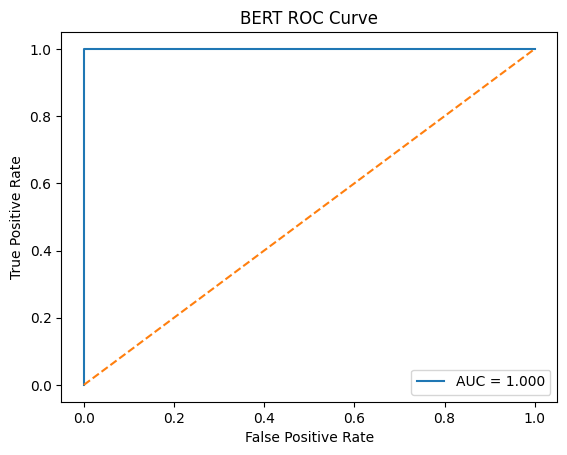

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BERT ROC Curve")
plt.legend()
plt.show()
